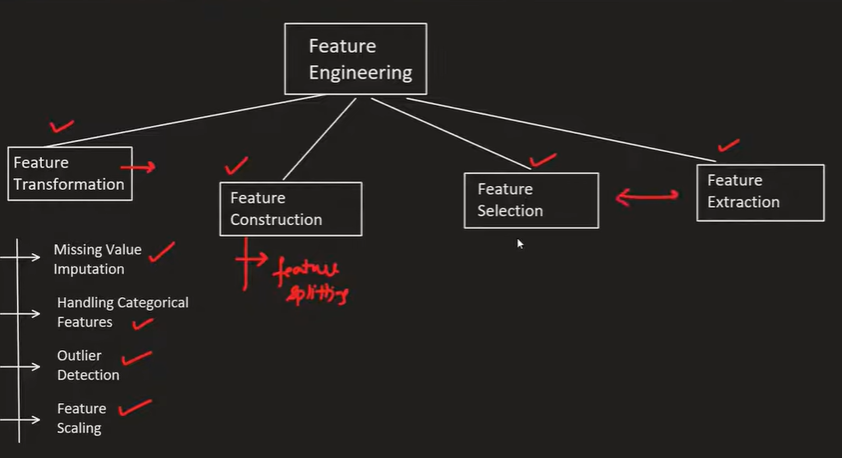

#  Feature Construction

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')[['Age','Pclass','SibSp','Parch','Survived']]

In [3]:

df.head()

,Age,Pclass,SibSp,Parch,Survived
0,22.0,3,1,0,0
1,38.0,1,1,0,1
2,26.0,3,0,0,1
3,35.0,1,1,0,1
4,35.0,3,0,0,0


In [4]:

df.dropna(inplace=True)

In [5]:

df.head()

,Age,Pclass,SibSp,Parch,Survived
0,22.0,3,1,0,0
1,38.0,1,1,0,1
2,26.0,3,0,0,1
3,35.0,1,1,0,1
4,35.0,3,0,0,0


In [6]:

X = df.iloc[:,0:4]
y = df.iloc[:,-1]

In [7]:

X.head()

,Age,Pclass,SibSp,Parch
0,22.0,3,1,0
1,38.0,1,1,0
2,26.0,3,0,0
3,35.0,1,1,0
4,35.0,3,0,0


In [8]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [9]:
# Compute the mean accuracy of a Logistic Regression model using 20-fold cross-validation
# cross_val_score:
# - evaluates LogisticRegression on the dataset (X, y)
# - scoring='accuracy' means we're using classification accuracy as the evaluation metric
# - cv=20 means the dataset is split into 20 folds for cross-validation
# np.mean(...) calculates the average accuracy across all 20 folds

mean_accuracy = np.mean(cross_val_score(LogisticRegression(), X, y, scoring='accuracy', cv=20))

# Print the mean accuracy
print(mean_accuracy)

0.6933333333333332



# **Applying Feature Construction**

In [10]:
X['Family_size'] = X['SibSp'] + X['Parch'] + 1

In [11]:
X.head()

,Age,Pclass,SibSp,Parch,Family_size
0,22.0,3,1,0,2
1,38.0,1,1,0,2
2,26.0,3,0,0,1
3,35.0,1,1,0,2
4,35.0,3,0,0,1


In [13]:
def myfunc(num):
    # Check if the number represents a single individual
    if num == 1:
        # Category: alone
        return 0
    elif num > 1 and num <= 4:
        # Category: small family (2 to 4 members)
        return 1
    else:
        # Category: large family (more than 4 members)
        return 2


In [17]:

myfunc(11)

2

In [19]:
# Apply the 'myfunc' function to each value in the 'Family_size' column
# This creates a new column 'Family_type' in the DataFrame X
# The values will be:
#   0 for individuals (alone)
#   1 for small families (2–4 members)
#   2 for large families (5+ members)
X['Family_type'] = X['Family_size'].apply(myfunc)


In [20]:

X.head()

,Age,Pclass,SibSp,Parch,Family_size,Family_type
0,22.0,3,1,0,2,1
1,38.0,1,1,0,2,1
2,26.0,3,0,0,1,0
3,35.0,1,1,0,2,1
4,35.0,3,0,0,1,0


In [21]:
# Drop the columns 'SibSp', 'Parch', and 'Family_size' from the DataFrame X
# These columns are no longer needed, likely because their information is now summarized
# in the new 'Family_type' column created earlier
# 'inplace=True' means the DataFrame X is modified directly without needing to reassign it
X.drop(columns=['SibSp', 'Parch', 'Family_size'], inplace=True)


In [22]:

X.head()

,Age,Pclass,Family_type
0,22.0,3,1
1,38.0,1,1
2,26.0,3,0
3,35.0,1,1
4,35.0,3,0


In [23]:
np.mean(cross_val_score(LogisticRegression(),X,y,scoring='accuracy',cv=20))

np.float64(0.7003174603174602)


# **Feature Splitting**

In [24]:

df = pd.read_csv('train.csv')

In [25]:

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:

df['Name']

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [27]:
# Extract the title (e.g., Mr, Mrs, Miss) from the 'Name' column in the DataFrame df
# Step-by-step breakdown:

# 1. df['Name'].str.split(', ', expand=True)
#    - Splits the 'Name' string into two parts at the comma:
#      Example: "Smith, Mr. John" → ["Smith", "Mr. John"]
#    - [1] selects the second part: "Mr. John"

# 2. .str.split('.', expand=True)[0]
#    - Splits "Mr. John" at the period: ["Mr", " John"]
#    - [0] selects the title: "Mr"

# The final result is stored in a new column 'Title'
df['Title'] = df['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]


In [28]:
df['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]

,0
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rev
887,Miss
888,Miss
889,Mr


In [29]:
df[['Title','Name']]

,Title,Name
0,Mr,"Braund, Mr. Owen Harris"
1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,Miss,"Heikkinen, Miss. Laina"
3,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,Mr,"Allen, Mr. William Henry"
...,...,...
886,Rev,"Montvila, Rev. Juozas"
887,Miss,"Graham, Miss. Margaret Edith"
888,Miss,"Johnston, Miss. Catherine Helen ""Carrie"""
889,Mr,"Behr, Mr. Karl Howell"


In [31]:
df.groupby('Title')['Survived'].mean().sort_values(ascending=False)


,Survived
Title,
Lady,1.000000
Ms,1.000000
Sir,1.000000
Mme,1.000000
the Countess,1.000000
Mlle,1.000000
Mrs,0.792000
Miss,0.697802
Master,0.575000


In [32]:
df['Is_Married'] = 0
df['Is_Married'].loc[df['Title'] == 'Mrs'] = 1

/tmp/ipython-input-32-2254989826.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Is_Married'].loc[df['Title'] == 'Mrs'] = 1
/tmp/ipython-input-32-2254989826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [33]:
df['Is_Married']

,Is_Married
0,0
1,1
2,0
3,1
4,0
...,...
886,0
887,0
888,0
889,0
